# Week 11 & 12 — Dimensionality Reduction: PCA and t-SNE
**Hack-O-Week | 5th Semester | SIT Nagpur**

**Goal:** Understand the intuition and applications of PCA and t-SNE and see how they reduce / visualise high-dimensional data.

**Why reduce dimensions?** Data with 100s of features is hard to visualise, slow to train and suffers from the *curse of dimensionality*. We keep the most useful information in fewer dimensions.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
np.random.seed(0)

## 1. PCA — Principal Component Analysis
**Simple intuition:** Imagine photographing a 3D object. Choose the camera angle that shows the **most spread (variance)** — that angle keeps the most information. PCA finds those best "angles" (called principal components).

**Steps (5-mark style):**
1. **Standardise** the data (mean 0, std 1).
2. Compute the **covariance matrix**.
3. Find **eigenvectors** (directions) and **eigenvalues** (importance = variance along the direction).
4. Sort by eigenvalue, **pick top k** components.
5. **Project** the data onto these k components → new low-dimensional data.

PC1 = direction of maximum variance; PC2 = next best direction, **perpendicular** to PC1.

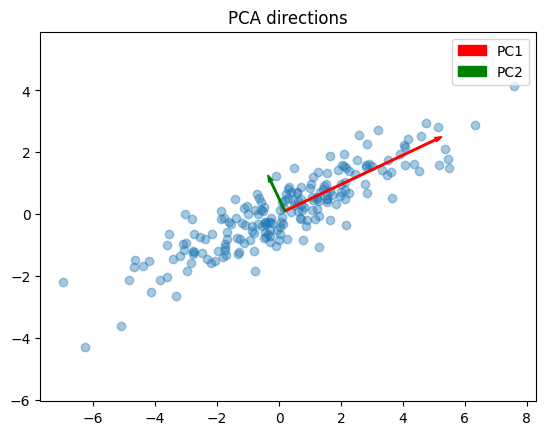

Explained variance ratio: [0.963 0.037]


In [2]:
# 2D toy example: correlated data -> PC1 follows the long direction
rng = np.random.RandomState(1)
pts = rng.randn(200,2) @ np.array([[2.5,1.2],[0,0.6]])
p = PCA(2).fit(pts); c = pts.mean(0)
plt.scatter(pts[:,0],pts[:,1],alpha=.4)
for vec,var,col,nm in zip(p.components_,p.explained_variance_,['r','g'],['PC1','PC2']):
    plt.arrow(*c,*(vec*np.sqrt(var)*2),color=col,width=.05,label=nm)
plt.axis('equal'); plt.legend(); plt.title('PCA directions'); plt.show()
print("Explained variance ratio:", p.explained_variance_ratio_.round(3))

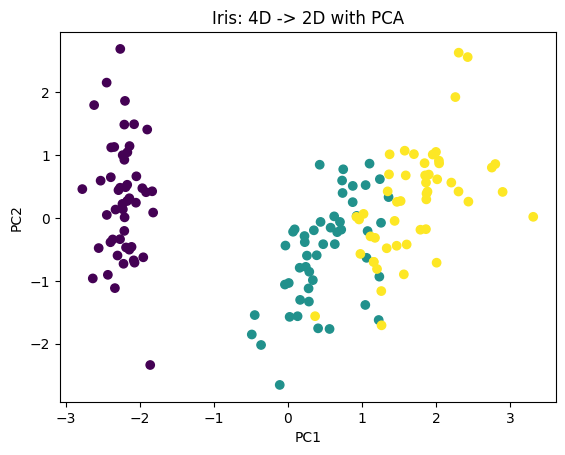

Variance kept by 2 PCs: 95.8%


In [3]:
# Iris (4 features) -> 2 components
iris = load_iris(); Xi = StandardScaler().fit_transform(iris.data)
pca2 = PCA(n_components=2); Z = pca2.fit_transform(Xi)
plt.scatter(Z[:,0],Z[:,1],c=iris.target,cmap='viridis'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Iris: 4D -> 2D with PCA'); plt.show()
print("Variance kept by 2 PCs: %.1f%%" % (pca2.explained_variance_ratio_.sum()*100))

### Choosing the number of components
Plot **cumulative explained variance** and keep enough components to retain ~95% of information. Real example: handwritten digits (64 pixels per image).

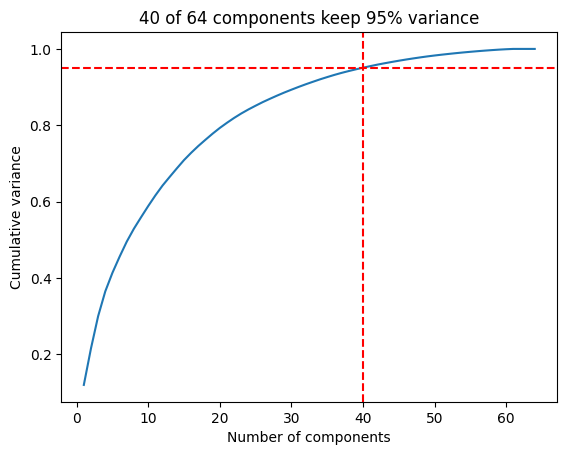

In [4]:
digits = load_digits(); Xd = StandardScaler().fit_transform(digits.data); yd = digits.target
pca_full = PCA().fit(Xd); cum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = int(np.argmax(cum>=.95))+1
plt.plot(range(1,65),cum); plt.axhline(.95,ls='--',c='r'); plt.axvline(k95,ls='--',c='r')
plt.xlabel('Number of components'); plt.ylabel('Cumulative variance'); plt.title(f'{k95} of 64 components keep 95% variance'); plt.show()

All 64 features   : accuracy = 0.967
40 PCA components : accuracy = 0.964


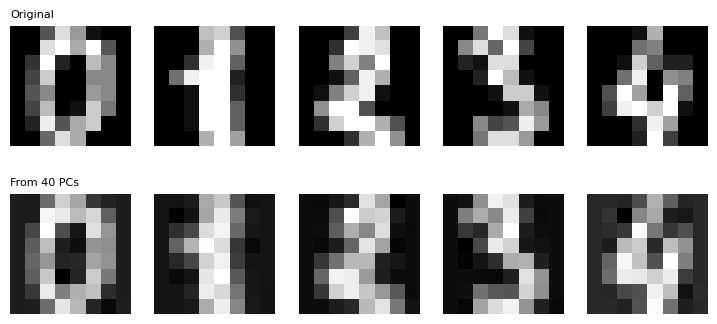

In [5]:
# Application 1: faster models with fewer features
Xtr,Xte,ytr,yte = train_test_split(Xd,yd,test_size=.25,random_state=0)
full = LogisticRegression(max_iter=2000).fit(Xtr,ytr)
pca95 = PCA(n_components=k95).fit(Xtr)
red = LogisticRegression(max_iter=2000).fit(pca95.transform(Xtr),ytr)
print(f"All 64 features   : accuracy = {full.score(Xte,yte):.3f}")
print(f"{k95} PCA components : accuracy = {red.score(pca95.transform(Xte),yte):.3f}")

# Application 2: image compression / reconstruction
fig,ax = plt.subplots(2,5,figsize=(9,4))
for i in range(5):
    ax[0,i].imshow(digits.data[i].reshape(8,8),cmap='gray'); ax[0,i].axis('off')
    rec = pca95.inverse_transform(pca95.transform(Xd[i:i+1])) 
    rec = StandardScaler().fit(digits.data).inverse_transform(rec)
    ax[1,i].imshow(rec.reshape(8,8),cmap='gray'); ax[1,i].axis('off')
ax[0,0].set_title('Original',fontsize=8,loc='left'); ax[1,0].set_title(f'From {k95} PCs',fontsize=8,loc='left'); plt.show()

## 2. t-SNE — t-distributed Stochastic Neighbour Embedding (intuition)
**Simple intuition:** PCA keeps the big overall shape. t-SNE cares about **neighbours**: points that are close together in high dimensions should stay close in 2D, and far points should stay far. Think of arranging friends on a 2D map so that close friends sit near each other.

**Steps (intuition):**
1. In high-D, convert distances between points into **probabilities** of being neighbours.
2. Place points randomly in 2D.
3. In 2D, compute similar neighbour probabilities (using a t-distribution).
4. **Move points** step by step to make 2D probabilities match high-D ones (minimise KL-divergence).

**Key parameter:** `perplexity` (≈ number of neighbours considered, usually 5–50).

**Cautions:** used mainly for **visualisation**; cluster sizes and distances between clusters are *not* reliable; slower than PCA; results vary with perplexity and random seed.

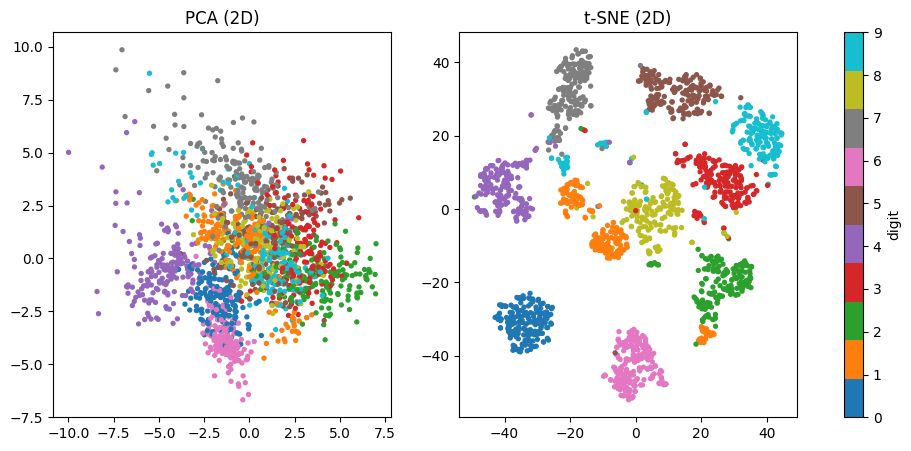

In [6]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=0)
Zt = tsne.fit_transform(Xd)
Zp = PCA(2).fit_transform(Xd)
fig,ax = plt.subplots(1,2,figsize=(12,5))
for a,Zx,t in zip(ax,[Zp,Zt],['PCA (2D)','t-SNE (2D)']):
    sc = a.scatter(Zx[:,0],Zx[:,1],c=yd,cmap='tab10',s=8); a.set_title(t)
plt.colorbar(sc,ax=ax,label='digit'); plt.show()

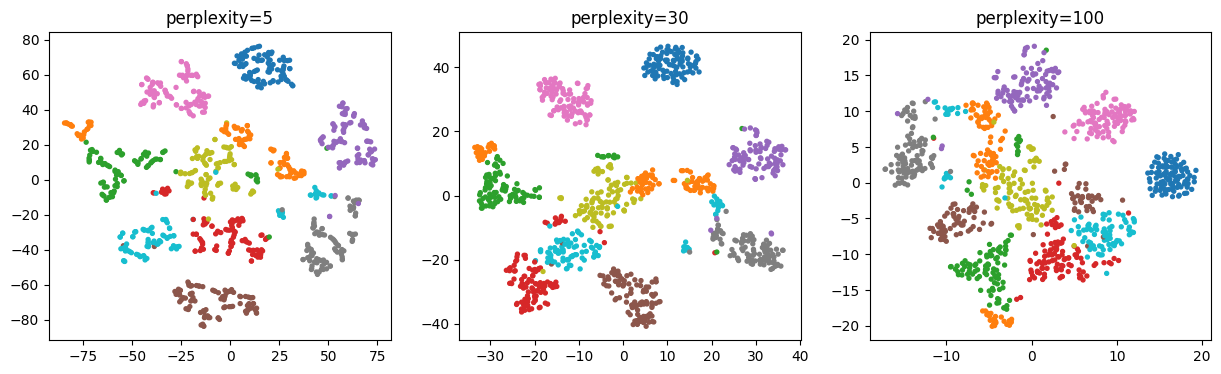

In [7]:
# Effect of perplexity
fig,ax = plt.subplots(1,3,figsize=(15,4))
for a,pp in zip(ax,[5,30,100]):
    Zx = TSNE(perplexity=pp,init='pca',random_state=0).fit_transform(Xd[:1000])
    a.scatter(Zx[:,0],Zx[:,1],c=yd[:1000],cmap='tab10',s=8); a.set_title(f'perplexity={pp}')
plt.show()

## PCA vs t-SNE
| Point | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Preserves | Global variance / structure | Local neighbourhoods |
| Speed | Fast | Slow |
| Output reusable on new data | Yes (`transform`) | No (re-run) |
| Main use | Compression, noise removal, speed-up, preprocessing | 2D/3D visualisation of clusters |
| Deterministic | Yes | No (depends on seed) |

**Tip:** run PCA first (e.g. to 30-50 dims), then t-SNE for faster and cleaner plots.

**Applications:** image compression, face recognition (eigenfaces), gene-expression analysis, visualising word embeddings, customer segmentation, anomaly detection.